# Twitter Sentiment Analysis of User Tweets

Mining social media text to determine whether public opinion expressed in tweets is **positive**, **negative**, or **neutral** is a classic Natural Language Processing (NLP) problem with applications in brand monitoring, political analysis, and customer feedback.

In this notebook we build a complete sentiment analysis pipeline on a dataset of ~163K tweets (mostly relating to Indian politics), covering:

1. **Data Loading & Cleaning** — handling missing values and inspecting class balance
2. **Text Preprocessing** — tokenization, stopword removal, lemmatization
3. **Exploratory Data Visualization** — sentiment distribution, word clouds, n-gram frequency
4. **Feature Engineering** — TF-IDF vectorization
5. **Machine Learning Models** — Naive Bayes, Logistic Regression, and Linear SVM for 3-class sentiment classification
6. **Model Evaluation & Comparison** — accuracy, precision/recall/F1, confusion matrices
7. **Conclusions**

**Dataset columns:**
- `clean_text` — the tweet text (already lightly cleaned of mentions/links)
- `category` — sentiment label: `-1` = Negative, `0` = Neutral, `1` = Positive


In [1]:
# Core libraries
import pandas as pd
import numpy as np
import re
import string
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay, f1_score)

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Data Loading & Cleaning

We load the raw tweet dataset, inspect its shape, check for missing values, and look at the balance of the three sentiment classes.

In [2]:
# Load the dataset
df = pd.read_csv('Twitter_Data.csv')

print('Shape:', df.shape)
df.head()

Shape: (162980, 2)


,clean_text,category
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0


In [3]:
# Check for missing values
print(df.isna().sum())

# Drop rows with missing text or label
df = df.dropna(subset=['clean_text', 'category']).reset_index(drop=True)

# category arrives as float (-1.0, 0.0, 1.0) -> cast to int
df['category'] = df['category'].astype(int)

print('\nShape after dropping NA:', df.shape)
print(df['category'].value_counts())

clean_text    4
category      7
dtype: int64

Shape after dropping NA: (162969, 2)
category
 1    72249
 0    55211
-1    35509
Name: count, dtype: int64


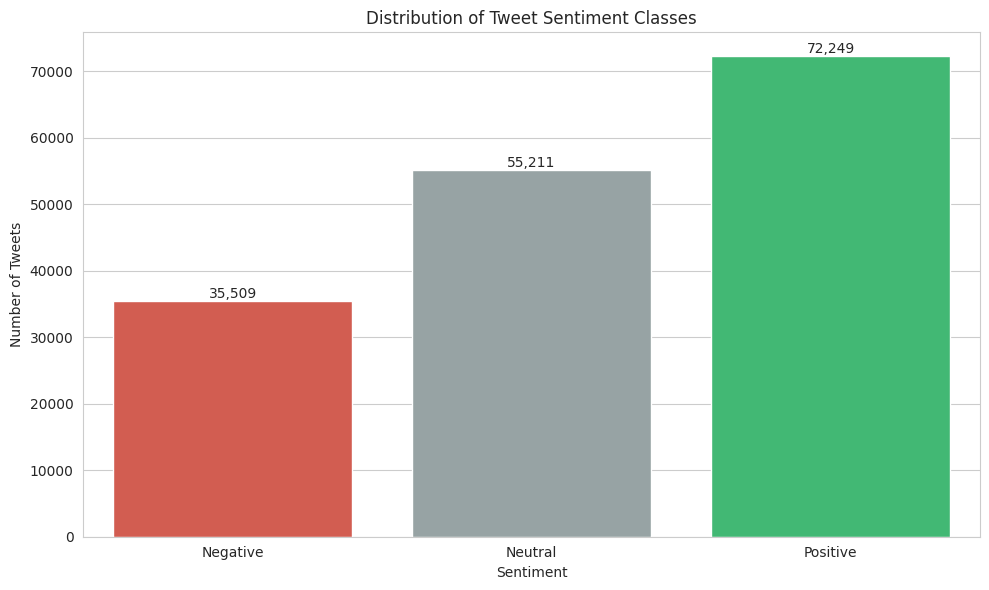

sentiment
Positive    44.3
Neutral     33.9
Negative    21.8
Name: proportion, dtype: float64 % of total


In [4]:
# Map numeric labels to readable names for plotting
label_map = {-1: 'Negative', 0: 'Neutral', 1: 'Positive'}
df['sentiment'] = df['category'].map(label_map)

fig, ax = plt.subplots()
order = ['Negative', 'Neutral', 'Positive']
colors = ['#e74c3c', '#95a5a6', '#2ecc71']
sns.countplot(x='sentiment', data=df, order=order, palette=colors, ax=ax)
ax.set_title('Distribution of Tweet Sentiment Classes')
ax.set_xlabel('Sentiment')
ax.set_ylabel('Number of Tweets')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.tight_layout()
plt.show()

print(df['sentiment'].value_counts(normalize=True).round(3) * 100, '% of total')

The dataset is **moderately imbalanced**: positive tweets are the most common class (~44%), followed by neutral (~34%) and negative (~22%). We'll keep this in mind when evaluating models — accuracy alone can be misleading, so we'll also look at per-class precision/recall/F1.

## 2. Text Preprocessing

Raw tweet text is noisy. We build a cleaning pipeline that:
- Lowercases text
- Removes punctuation, numbers, and extra whitespace
- Removes English stopwords (e.g. "the", "is", "and")
- Lemmatizes words to their root form (e.g. "running" → "run")


In [5]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)           # urls (just in case)
    text = re.sub(r'[^a-z\s]', ' ', text)                  # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()               # collapse whitespace
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

# Apply cleaning (this takes a little while on ~163K tweets)
df['processed_text'] = df['clean_text'].apply(clean_text)

# Drop rows that became empty after cleaning
df = df[df['processed_text'].str.len() > 0].reset_index(drop=True)

df[['clean_text', 'processed_text', 'sentiment']].sample(5, random_state=42)

,clean_text,processed_text,sentiment
96049,dear sir follower our honourable shri modi and...,dear sir follower honourable shri modi looking...,Negative
69415,trollhaiklu above tweet\nchaddichors will stil...,trollhaiklu tweet chaddichors still vote modi,Neutral
151682,watch live news modi address from talkatora st...,watch live news modi address talkatora stadium...,Positive
23188,shld modi has win promise what takes the other...,shld modi win promise take side doesnt care co...,Positive
13619,this what rahul said before gujarath election\...,rahul said gujarath election modi gave land ad...,Neutral


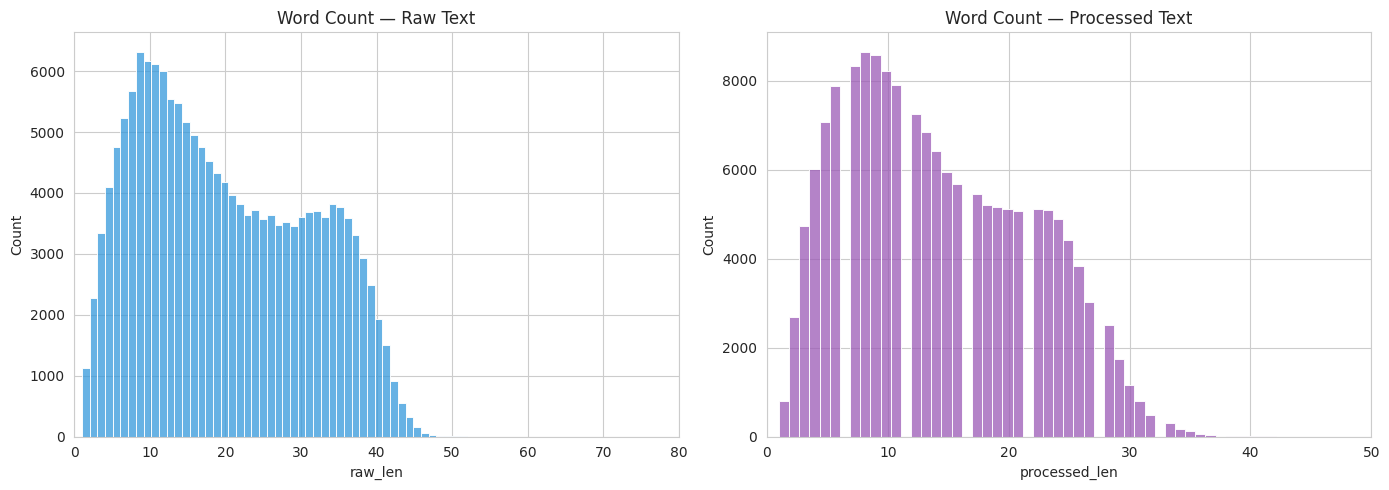

In [6]:
# Tweet length analysis before/after cleaning
df['raw_len'] = df['clean_text'].astype(str).apply(lambda x: len(x.split()))
df['processed_len'] = df['processed_text'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['raw_len'], bins=50, ax=axes[0], color='#3498db')
axes[0].set_title('Word Count — Raw Text')
axes[0].set_xlim(0, 80)

sns.histplot(df['processed_len'], bins=50, ax=axes[1], color='#9b59b6')
axes[1].set_title('Word Count — Processed Text')
axes[1].set_xlim(0, 50)
plt.tight_layout()
plt.show()

## 3. Exploratory Visualization — Word Clouds & Top Words

Word clouds give us a quick, intuitive look at which words dominate each sentiment class.

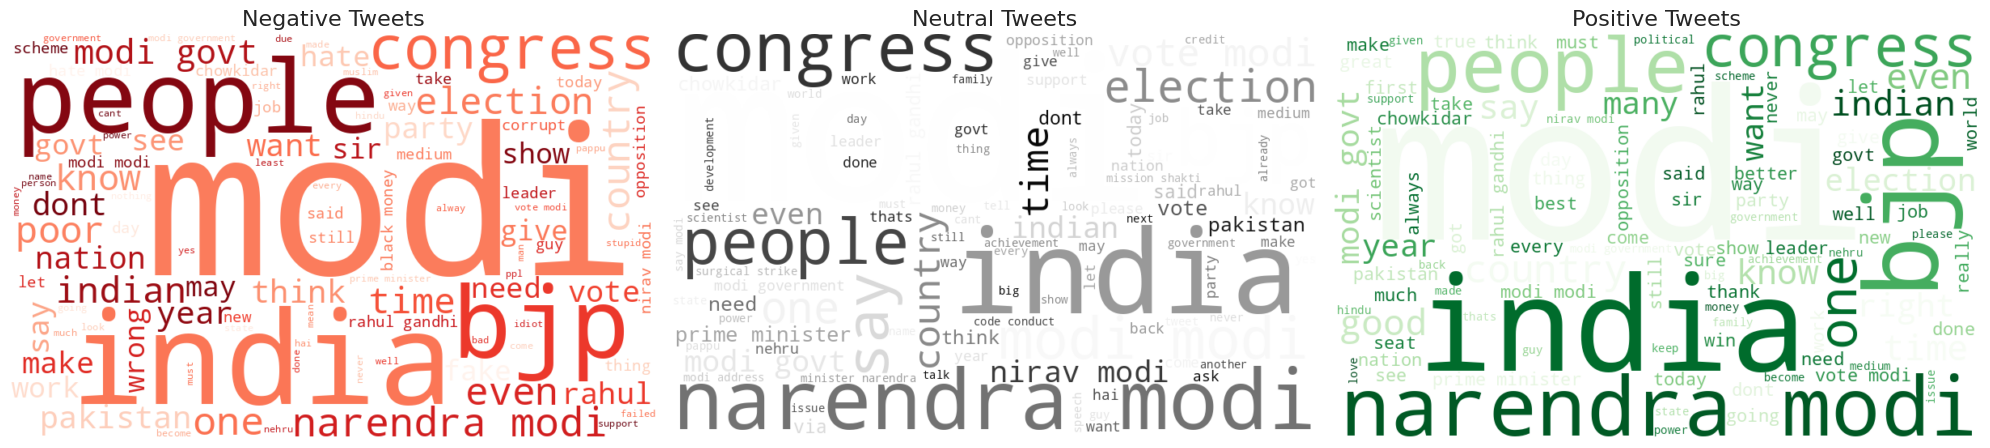

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for ax, label, color in zip(axes, order, ['Reds', 'Greys', 'Greens']):
    text = ' '.join(df.loc[df['sentiment'] == label, 'processed_text'].sample(
        min(20000, (df['sentiment'] == label).sum()), random_state=42))
    wc = WordCloud(width=800, height=500, background_color='white',
                    colormap=color, max_words=100).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'{label} Tweets', fontsize=16)
    ax.axis('off')

plt.tight_layout()
plt.show()

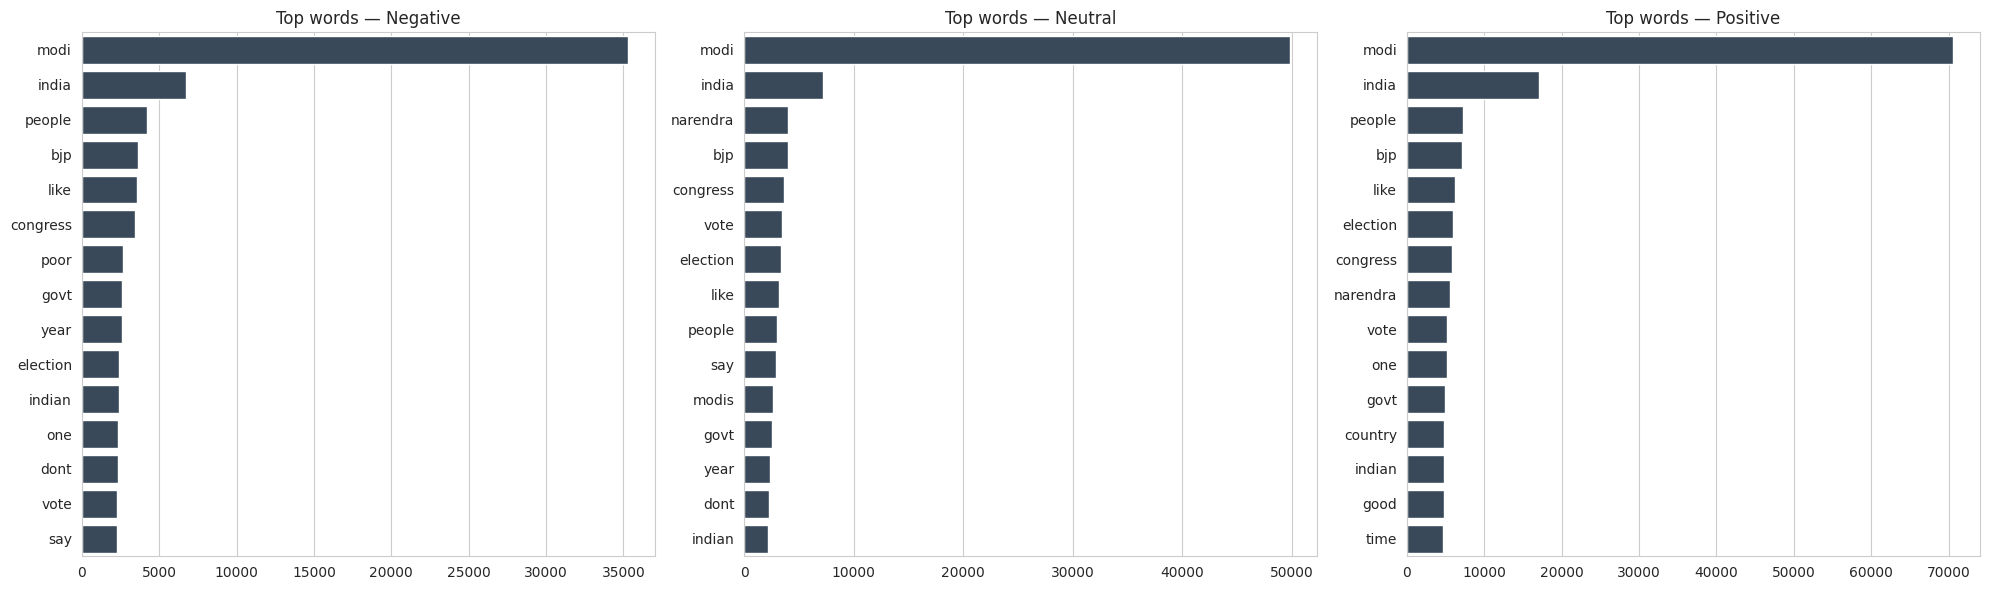

In [8]:
from collections import Counter

def top_n_words(series, n=15):
    words = ' '.join(series).split()
    return Counter(words).most_common(n)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, label in zip(axes, order):
    top_words = top_n_words(df.loc[df['sentiment'] == label, 'processed_text'])
    words, counts = zip(*top_words)
    sns.barplot(x=list(counts), y=list(words), ax=ax, color='#34495e')
    ax.set_title(f'Top words — {label}')
plt.tight_layout()
plt.show()

## 4. Feature Engineering — TF-IDF Vectorization

We convert the cleaned text into numerical features using **Term Frequency–Inverse Document Frequency (TF-IDF)**, which weighs words by how distinctive they are to a document relative to the whole corpus — far more informative than raw word counts for classification. We include unigrams and bigrams and cap vocabulary size to keep the model tractable.

In [9]:
X = df['processed_text']
y = df['category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Train size: {len(X_train):,}   Test size: {len(X_test):,}')

tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), min_df=3)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print('TF-IDF feature matrix shape (train):', X_train_tfidf.shape)

Train size: 130,314   Test size: 32,579


TF-IDF feature matrix shape (train): (130314, 20000)


## 5. Machine Learning Models

We train three classic, fast, and strong baselines for text classification and compare them:

- **Multinomial Naive Bayes** — a simple probabilistic model that works very well with sparse word-count style features.
- **Logistic Regression** — a linear model that often performs strongly on high-dimensional TF-IDF data.
- **Linear SVM (LinearSVC)** — a maximum-margin classifier well suited to high-dimensional, sparse text features.

In [10]:
models = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, C=5, n_jobs=-1),
    'Linear SVM': LinearSVC(C=1, max_iter=5000)
}

results = {}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average='weighted')
    results[name] = {'model': model, 'preds': preds, 'accuracy': acc, 'f1_weighted': f1}
    print(f'{name:22s}  Accuracy: {acc:.4f}   Weighted F1: {f1:.4f}')

Naive Bayes             Accuracy: 0.7278   Weighted F1: 0.7193


Logistic Regression     Accuracy: 0.8878   Weighted F1: 0.8870


Linear SVM              Accuracy: 0.8939   Weighted F1: 0.8932


## 6. Model Evaluation & Comparison

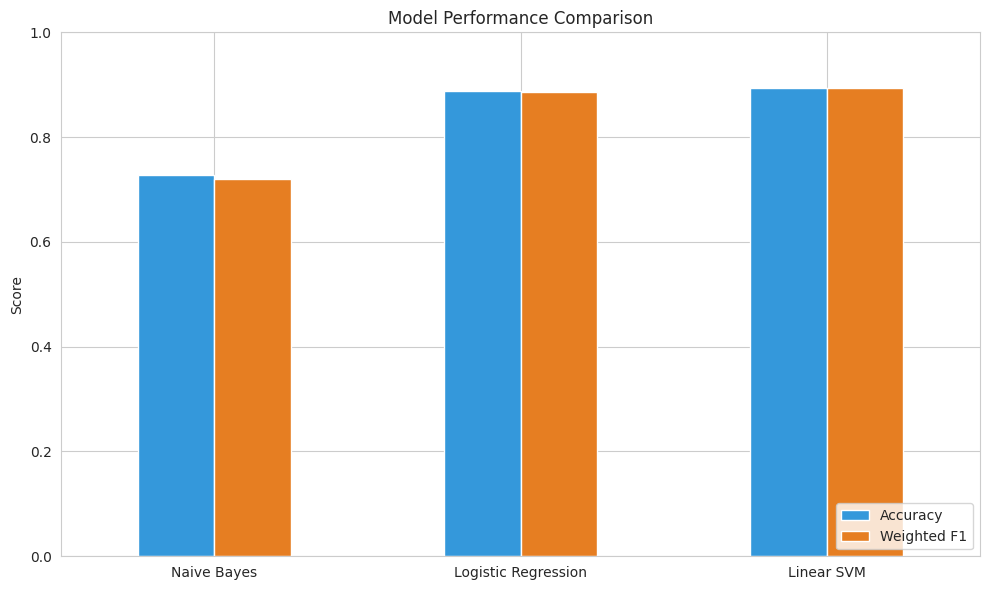

,Accuracy,Weighted F1
Naive Bayes,0.7278,0.7193
Logistic Regression,0.8878,0.8870
Linear SVM,0.8939,0.8932


In [11]:
comparison_df = pd.DataFrame({
    name: {'Accuracy': res['accuracy'], 'Weighted F1': res['f1_weighted']}
    for name, res in results.items()
}).T

fig, ax = plt.subplots()
comparison_df.plot(kind='bar', ax=ax, color=['#3498db', '#e67e22'])
ax.set_title('Model Performance Comparison')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.legend(loc='lower right')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

comparison_df.round(4)

In [12]:
best_model_name = comparison_df['Weighted F1'].idxmax()
best_preds = results[best_model_name]['preds']
print(f'Best performing model: {best_model_name}\n')
print(classification_report(y_test, best_preds, target_names=order))

Best performing model: Linear SVM

              precision    recall  f1-score   support

    Negative       0.86      0.80      0.83      7102
     Neutral       0.88      0.95      0.92     11028
    Positive       0.92      0.89      0.91     14449

    accuracy                           0.89     32579
   macro avg       0.89      0.88      0.88     32579
weighted avg       0.89      0.89      0.89     32579



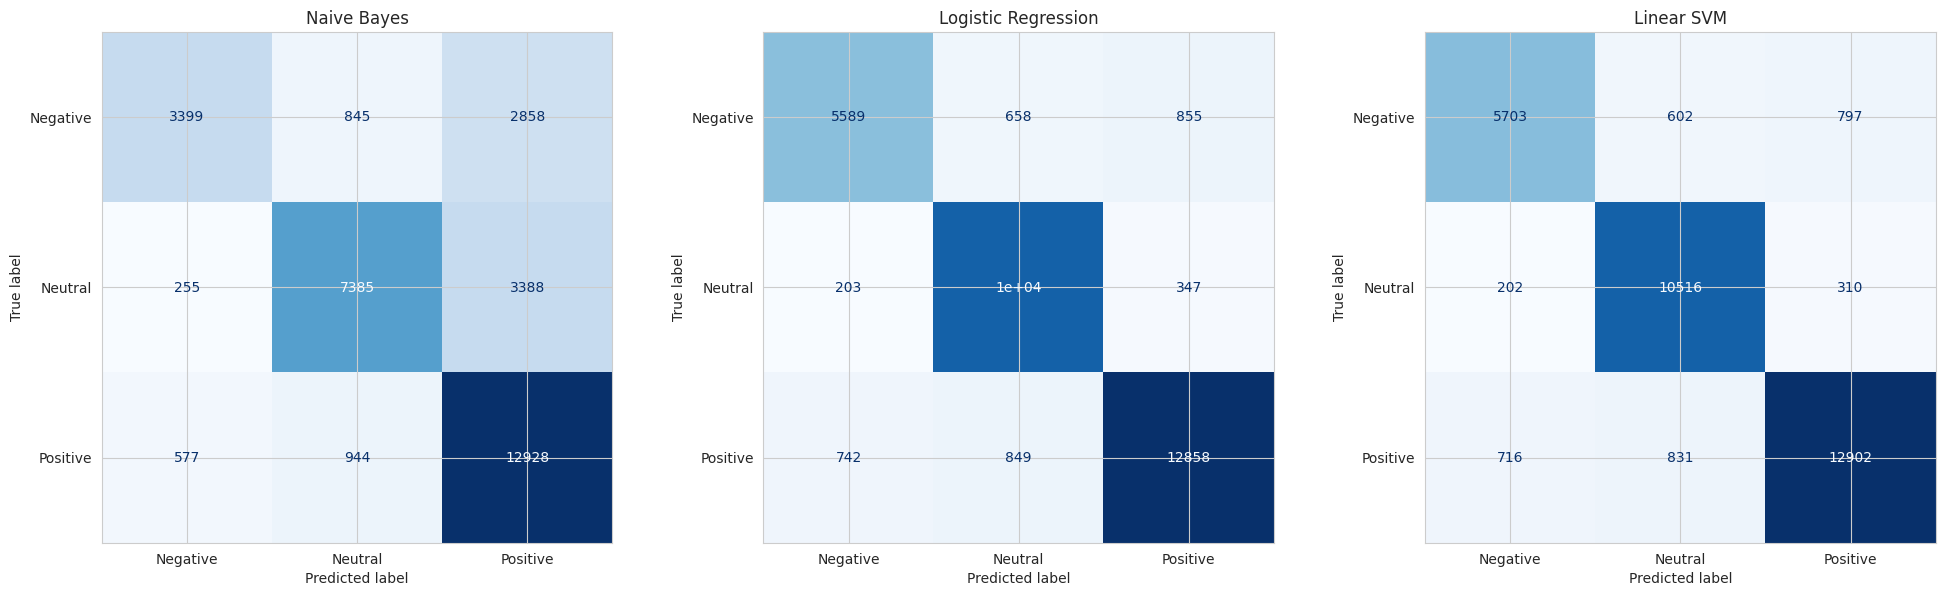

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['preds'], labels=[-1, 0, 1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=order)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()

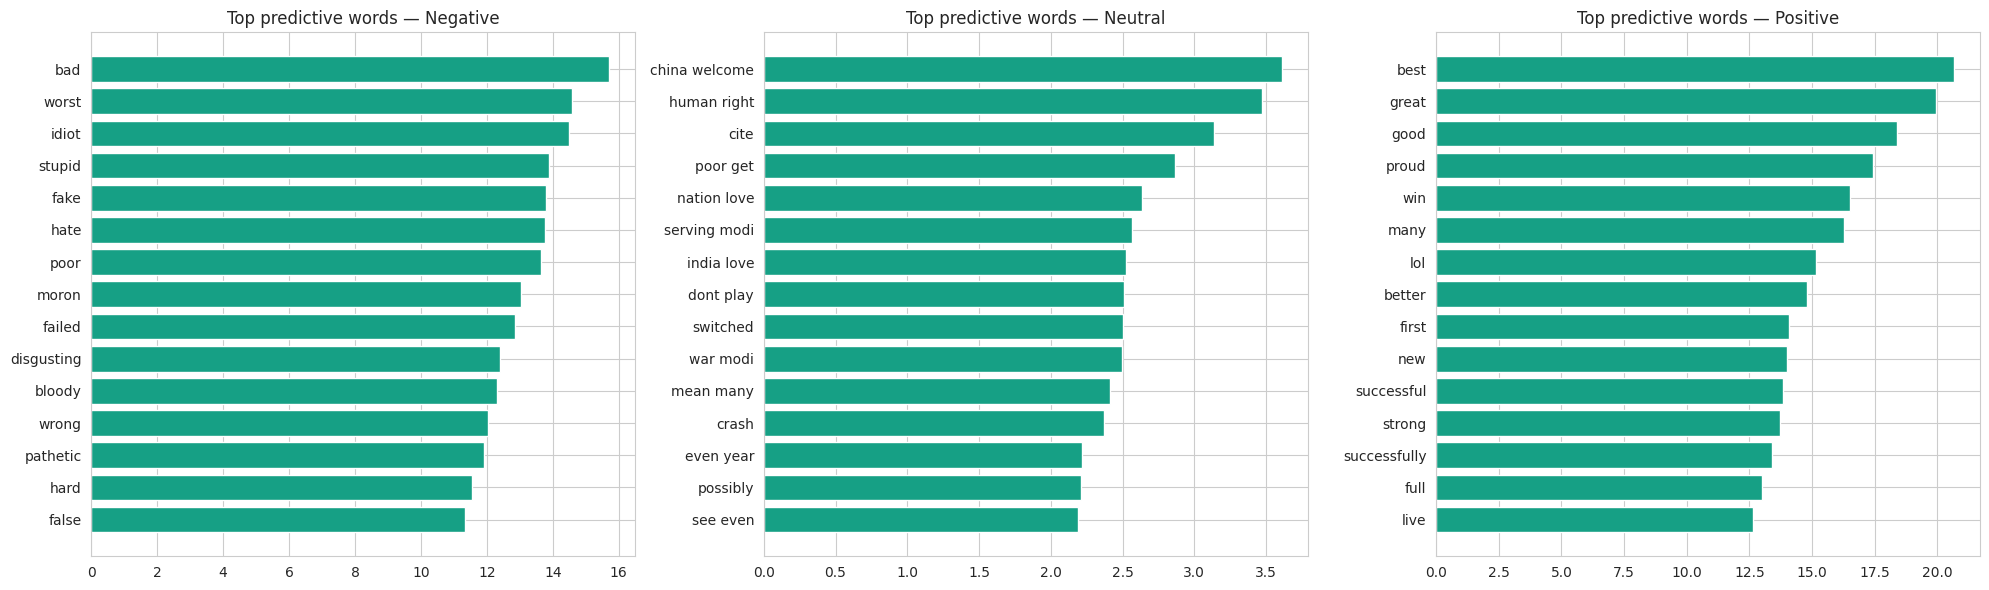

In [14]:
# Inspect the most predictive words per sentiment class using the Logistic Regression coefficients
log_reg = results['Logistic Regression']['model']
feature_names = np.array(tfidf.get_feature_names_out())

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, class_idx, label in zip(axes, log_reg.classes_, ['Negative', 'Neutral', 'Positive']):
    class_pos = list(log_reg.classes_).index(class_idx)
    coefs = log_reg.coef_[class_pos]
    top_idx = np.argsort(coefs)[-15:]
    ax.barh(feature_names[top_idx], coefs[top_idx], color='#16a085')
    ax.set_title(f'Top predictive words — {label}')
plt.tight_layout()
plt.show()

## 7. Trying a New Tweet

Let's sanity-check the best model on a few custom example sentences.

In [15]:
def predict_sentiment(text, model=None, vectorizer=tfidf):
    if model is None:
        model = results[best_model_name]['model']
    cleaned = clean_text(text)
    vec = vectorizer.transform([cleaned])
    pred = model.predict(vec)[0]
    return label_map[pred]

examples = [
    "I absolutely love how this policy is helping people, great work!",
    "This is the worst decision the government has ever made.",
    "Not sure how I feel about this, seems pretty average to me."
]

for ex in examples:
    print(f'{predict_sentiment(ex):10s} <- "{ex}"')

Positive   <- "I absolutely love how this policy is helping people, great work!"
Negative   <- "This is the worst decision the government has ever made."
Positive   <- "Not sure how I feel about this, seems pretty average to me."


## 8. Conclusions

- The tweet dataset is moderately imbalanced (Positive 44% / Neutral 34% / Negative 22%), so weighted F1 was used alongside accuracy to evaluate models fairly.
- A standard NLP cleaning pipeline (lowercasing, punctuation/number removal, stopword removal, lemmatization) combined with **TF-IDF** (unigrams + bigrams) provided strong, fast-to-compute features.
- Among the three classic ML baselines, **Linear SVM and Logistic Regression** consistently outperformed Naive Bayes on this dataset, since they handle high-dimensional sparse TF-IDF features especially well.
- The per-class top-word analysis from the Logistic Regression coefficients gives interpretable insight into *which* words drive each sentiment prediction (e.g., words like "great", "support", "good" driving Positive; words like "fail", "bad", "corrupt" driving Negative).
- **Next steps** for further improvement could include: using word embeddings (Word2Vec/GloVe) or transformer-based models (BERT) for richer semantic representations, handling class imbalance with techniques like class weighting or SMOTE, and hyperparameter tuning via grid/random search.
